   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154      0.3333

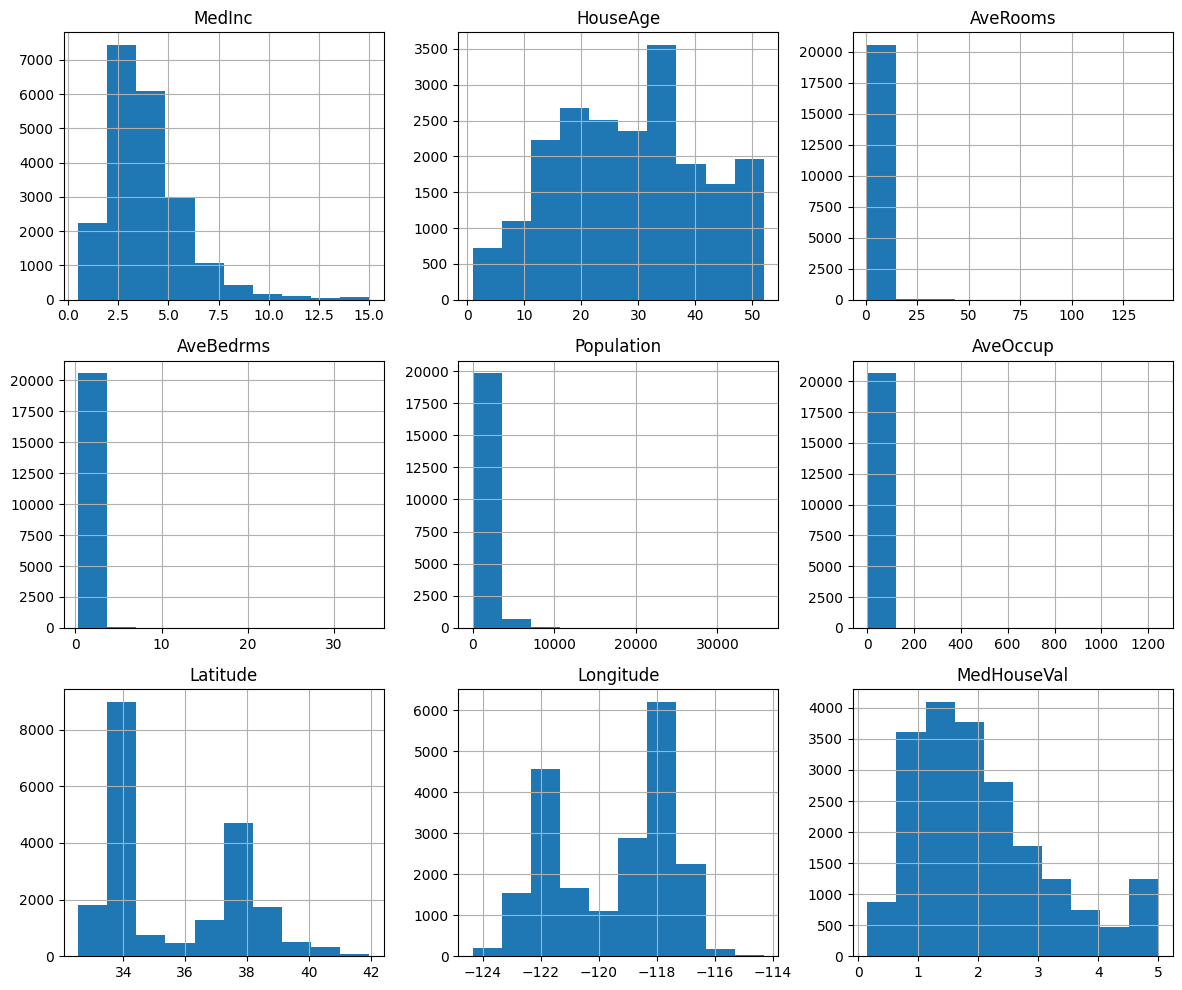

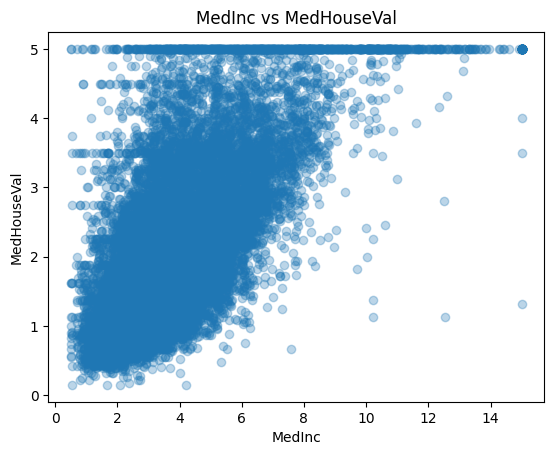

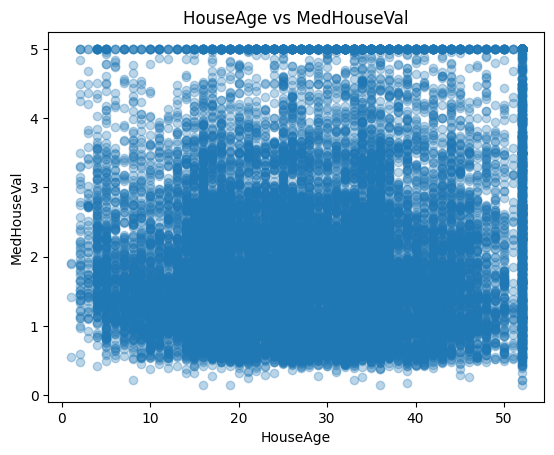

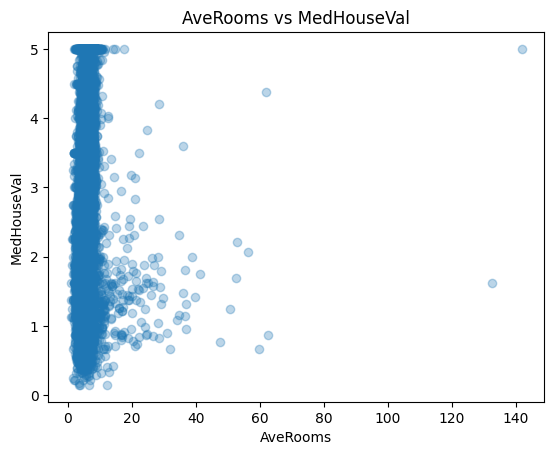

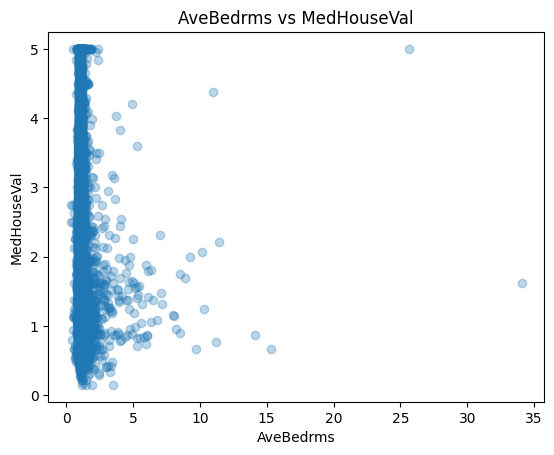

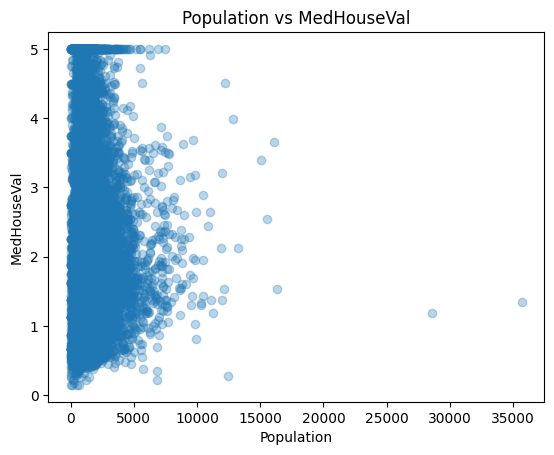

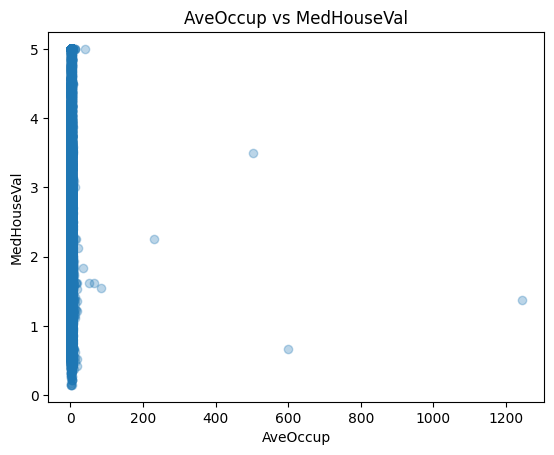

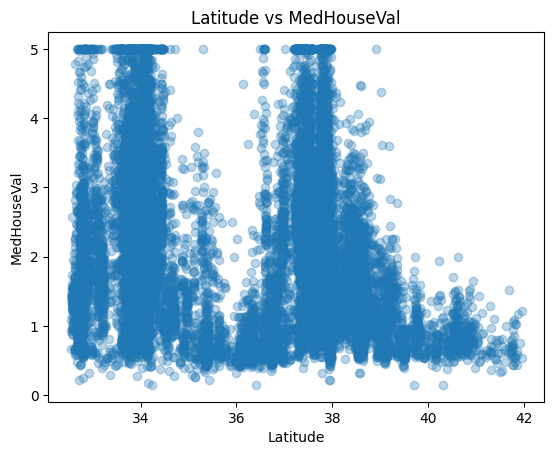

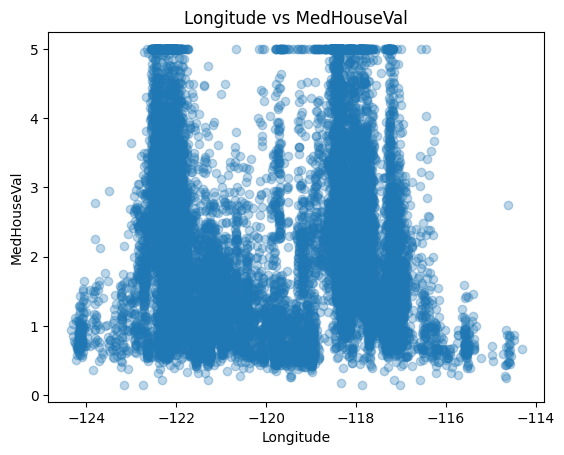

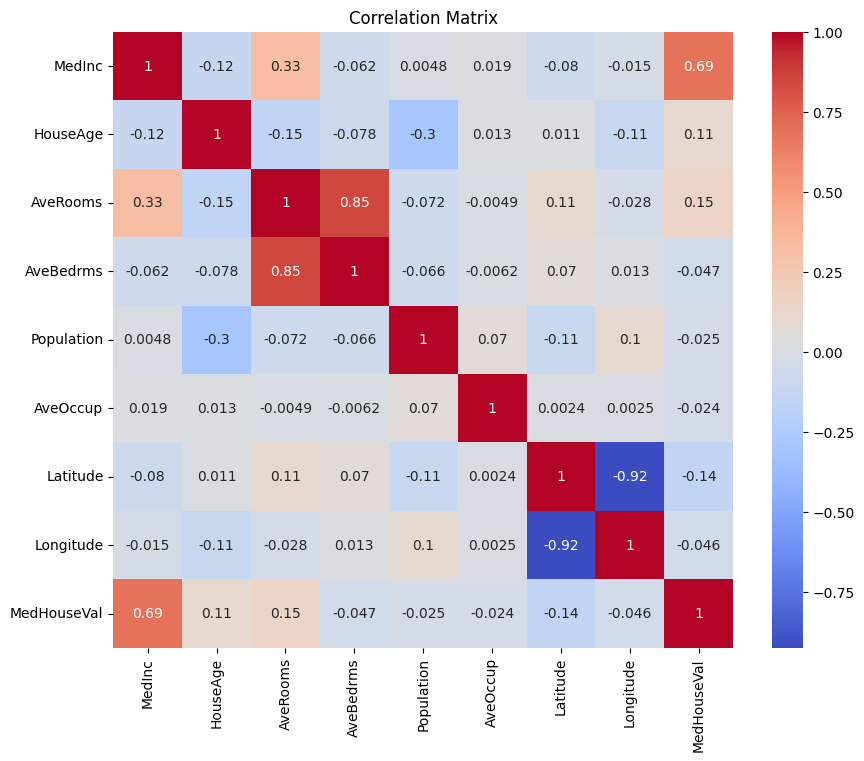

In [16]:
# ===== PART 1: Exploratory Data Analysis =====

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset from CSV
df = pd.read_csv("california_housing.csv")

# Show first rows
print(df.head())

# Summary statistics
print(df.describe())

# Check missing values
print(df.isnull().sum())

# Histograms of all variables
df.hist(figsize=(12,10))
plt.tight_layout()
plt.show()

# Scatter plots with target
features = df.columns.drop("MedHouseVal")

for feature in features:
    plt.figure()
    plt.scatter(df[feature], df['MedHouseVal'], alpha=0.3)
    plt.xlabel(feature)
    plt.ylabel("MedHouseVal")
    plt.title(f"{feature} vs MedHouseVal")
    plt.show()

# Correlation matrix
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [17]:
# ===== PART 2: Multiple Regression Model =====

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Load dataset from CSV
df = pd.read_csv("california_housing.csv")

# Separate predictors and target
X = df.drop("MedHouseVal", axis=1)
y = df["MedHouseVal"]

# Train/Test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Build regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Show coefficients in table
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

print("Regression coefficients:\n")
print(coefficients)
print("\n")
for feature, coef in zip(X.columns, model.coef_):
    print(f"{feature}: +1 unit → price changes by {coef:.4f}")

Regression coefficients:

      Feature  Coefficient
0      MedInc     0.448675
1    HouseAge     0.009724
2    AveRooms    -0.123323
3   AveBedrms     0.783145
4  Population    -0.000002
5    AveOccup    -0.003526
6    Latitude    -0.419792
7   Longitude    -0.433708


MedInc: +1 unit → price changes by 0.4487
HouseAge: +1 unit → price changes by 0.0097
AveRooms: +1 unit → price changes by -0.1233
AveBedrms: +1 unit → price changes by 0.7831
Population: +1 unit → price changes by -0.0000
AveOccup: +1 unit → price changes by -0.0035
Latitude: +1 unit → price changes by -0.4198
Longitude: +1 unit → price changes by -0.4337


      Feature           VIF
0       const  17082.623698
1      MedInc      2.501295
2    HouseAge      1.241254
3    AveRooms      8.342786
4   AveBedrms      6.994995
5  Population      1.138125
6    AveOccup      1.008324
7    Latitude      9.297624
8   Longitude      8.962263


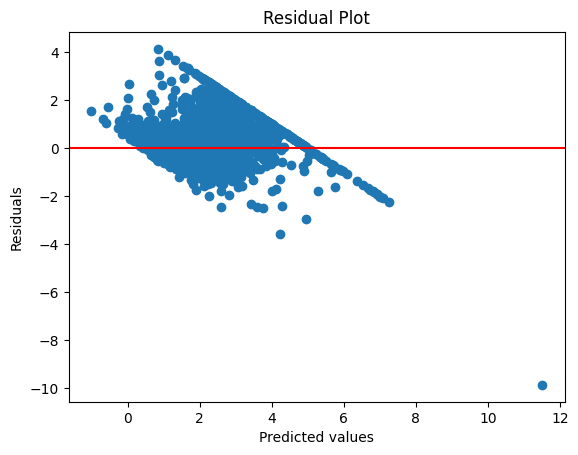

In [18]:
# ===== PART 3: Model Refinement =====

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Check VIF for multicollinearity
X_vif = sm.add_constant(X)

vif_data = pd.DataFrame()
vif_data["Feature"] = X_vif.columns
vif_data["VIF"] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(X_vif.shape[1])
]

print(vif_data)

# Predictions
y_pred = model.predict(X_test)

# Residuals
residuals = y_test - y_pred

# Residual plot
plt.scatter(y_pred, residuals)
plt.axhline(0, color='red')
plt.xlabel("Predicted values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()


In [19]:
# ===== PART 4: Interpret Results =====

# Sort coefficients by importance
coefficients_sorted = coefficients.sort_values(
    by="Coefficient",
    ascending=False
)

print(coefficients_sorted)

# Correlation with target
target_corr = df.corr()["MedHouseVal"].sort_values(ascending=False)

print(target_corr)

      Feature  Coefficient
3   AveBedrms     0.783145
0      MedInc     0.448675
1    HouseAge     0.009724
4  Population    -0.000002
5    AveOccup    -0.003526
2    AveRooms    -0.123323
6    Latitude    -0.419792
7   Longitude    -0.433708
MedHouseVal    1.000000
MedInc         0.688075
AveRooms       0.151948
HouseAge       0.105623
AveOccup      -0.023737
Population    -0.024650
Longitude     -0.045967
AveBedrms     -0.046701
Latitude      -0.144160
Name: MedHouseVal, dtype: float64


In [20]:
# ===== PART 5: Prediction & Model Evaluation =====

from sklearn.metrics import r2_score, mean_squared_error

# Predictions on test data
y_pred = model.predict(X_test)

# R² score
r2 = r2_score(y_test, y_pred)

# RMSE
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("Test R²:", r2)
print("Test RMSE:", rmse)

Test R²: 0.5757877060324513
Test RMSE: 0.7455813830127759
